In [4]:
import pickle
import os
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt


N_TIMESTEP_IN_REPLICA = 201
TEMPERATURE = 300

pickle_dir = "./pickle-cache/binding-free-energy_1d"
if not os.path.exists(pickle_dir):
    os.mkdir(pickle_dir)

pacs_com_distances = []
pacs_com_vectors = []
for trial in range(10):
    pickle_com_distances = pickle.load(open(f"./pickle-cache/com-features/pacs_com_distances_{trial}.pickle", "rb"))
    pacs_com_distances.append(pickle_com_distances.reshape((-1, N_TIMESTEP_IN_REPLICA, 1)))
    pickle_com_vectors = pickle.load(open(f"./pickle-cache/com-features/pacs_com_vectors_{trial}.pickle", "rb"))
    pacs_com_vectors.append(pickle_com_vectors.reshape((-1, N_TIMESTEP_IN_REPLICA, 3)))

trajs = pacs_com_distances

In [5]:
from sklearn.cluster import KMeans
import matplotlib


def cluster_trajs(trajs, n_clusters):
    clustering_model = KMeans(
        n_clusters=n_clusters,
        init="k-means++",
        n_init=10,
        max_iter=int(1e10),
        tol=1e-10,
        verbose=0,
        random_state=1,
        copy_x=True,
        algorithm="lloyd"
    )
    trajs_concat = np.concatenate(trajs)
    clustered_trajs_concat = clustering_model.fit_predict(trajs_concat)
    return clustered_trajs_concat.reshape(len(trajs), N_TIMESTEP_IN_REPLICA), clustering_model.cluster_centers_


def plot_clusters(ax, trajs, clustered_trajs, cluster_centers):
    trajs_concat = np.concatenate(trajs)
    clustered_trajs_concat = np.concatenate(clustered_trajs)

    ax.hist(trajs_concat, bins=n_clusters*5)
    for cluster_center in cluster_centers:
        ax.axvline(x=cluster_center, color="black", linewidth=0.2)

In [6]:
from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM
from deeptime.markov.tools import estimation
from deeptime.util.validation import implied_timescales
import deeptime.plots


def construct_msm(clustered_trajs, lagtimes):
    msm_models = {}
    stationary_distributions = {}

    for lagtime in lagtimes:
        count_estimator = TransitionCountEstimator(
            lagtime=lagtime,
            count_mode="sliding",
            n_states=None,
            sparse=False,
        )
        count_estimator.fit(clustered_trajs)
        count_model = count_estimator.fetch_model()

        msm_constructor = MaximumLikelihoodMSM(
            reversible=True,
            stationary_distribution_constraint=None,
            sparse=False,
            allow_disconnected=False,
            maxiter=int(1e10),
            maxerr=1e-10,
            connectivity_threshold=0,
            transition_matrix_tolerance=1e-10,
            lagtime=None,
            use_lcc=False,
        ) 

        try:
            msm_constructor.fit(count_model)
        except:
            continue

        msm_models[lagtime] = msm_constructor.fetch_model()
        largest_connected_set = estimation.largest_connected_set(count_model.count_matrix, directed=True)
        stationary_distributions[lagtime] = np.zeros(np.max(clustered_trajs)+1)
        stationary_distributions[lagtime][largest_connected_set] = msm_models[lagtime].stationary_distribution

    return msm_models, stationary_distributions


def plot_implied_timescales(ax, msm_models):
    deeptime.plots.plot_implied_timescales(
        implied_timescales(list(msm_models.values())),
        n_its=10,
        ax=ax,
        process=None,
        show_mle=True,
        show_sample_mean=True,
        show_sample_confidence=True,
        show_cutoff=True,
        sample_confidence=0.95,
        colors=None,
    )
    ax.set_xlim(0, np.max(list(msm_models.keys())))
    ax.set_yscale("log")

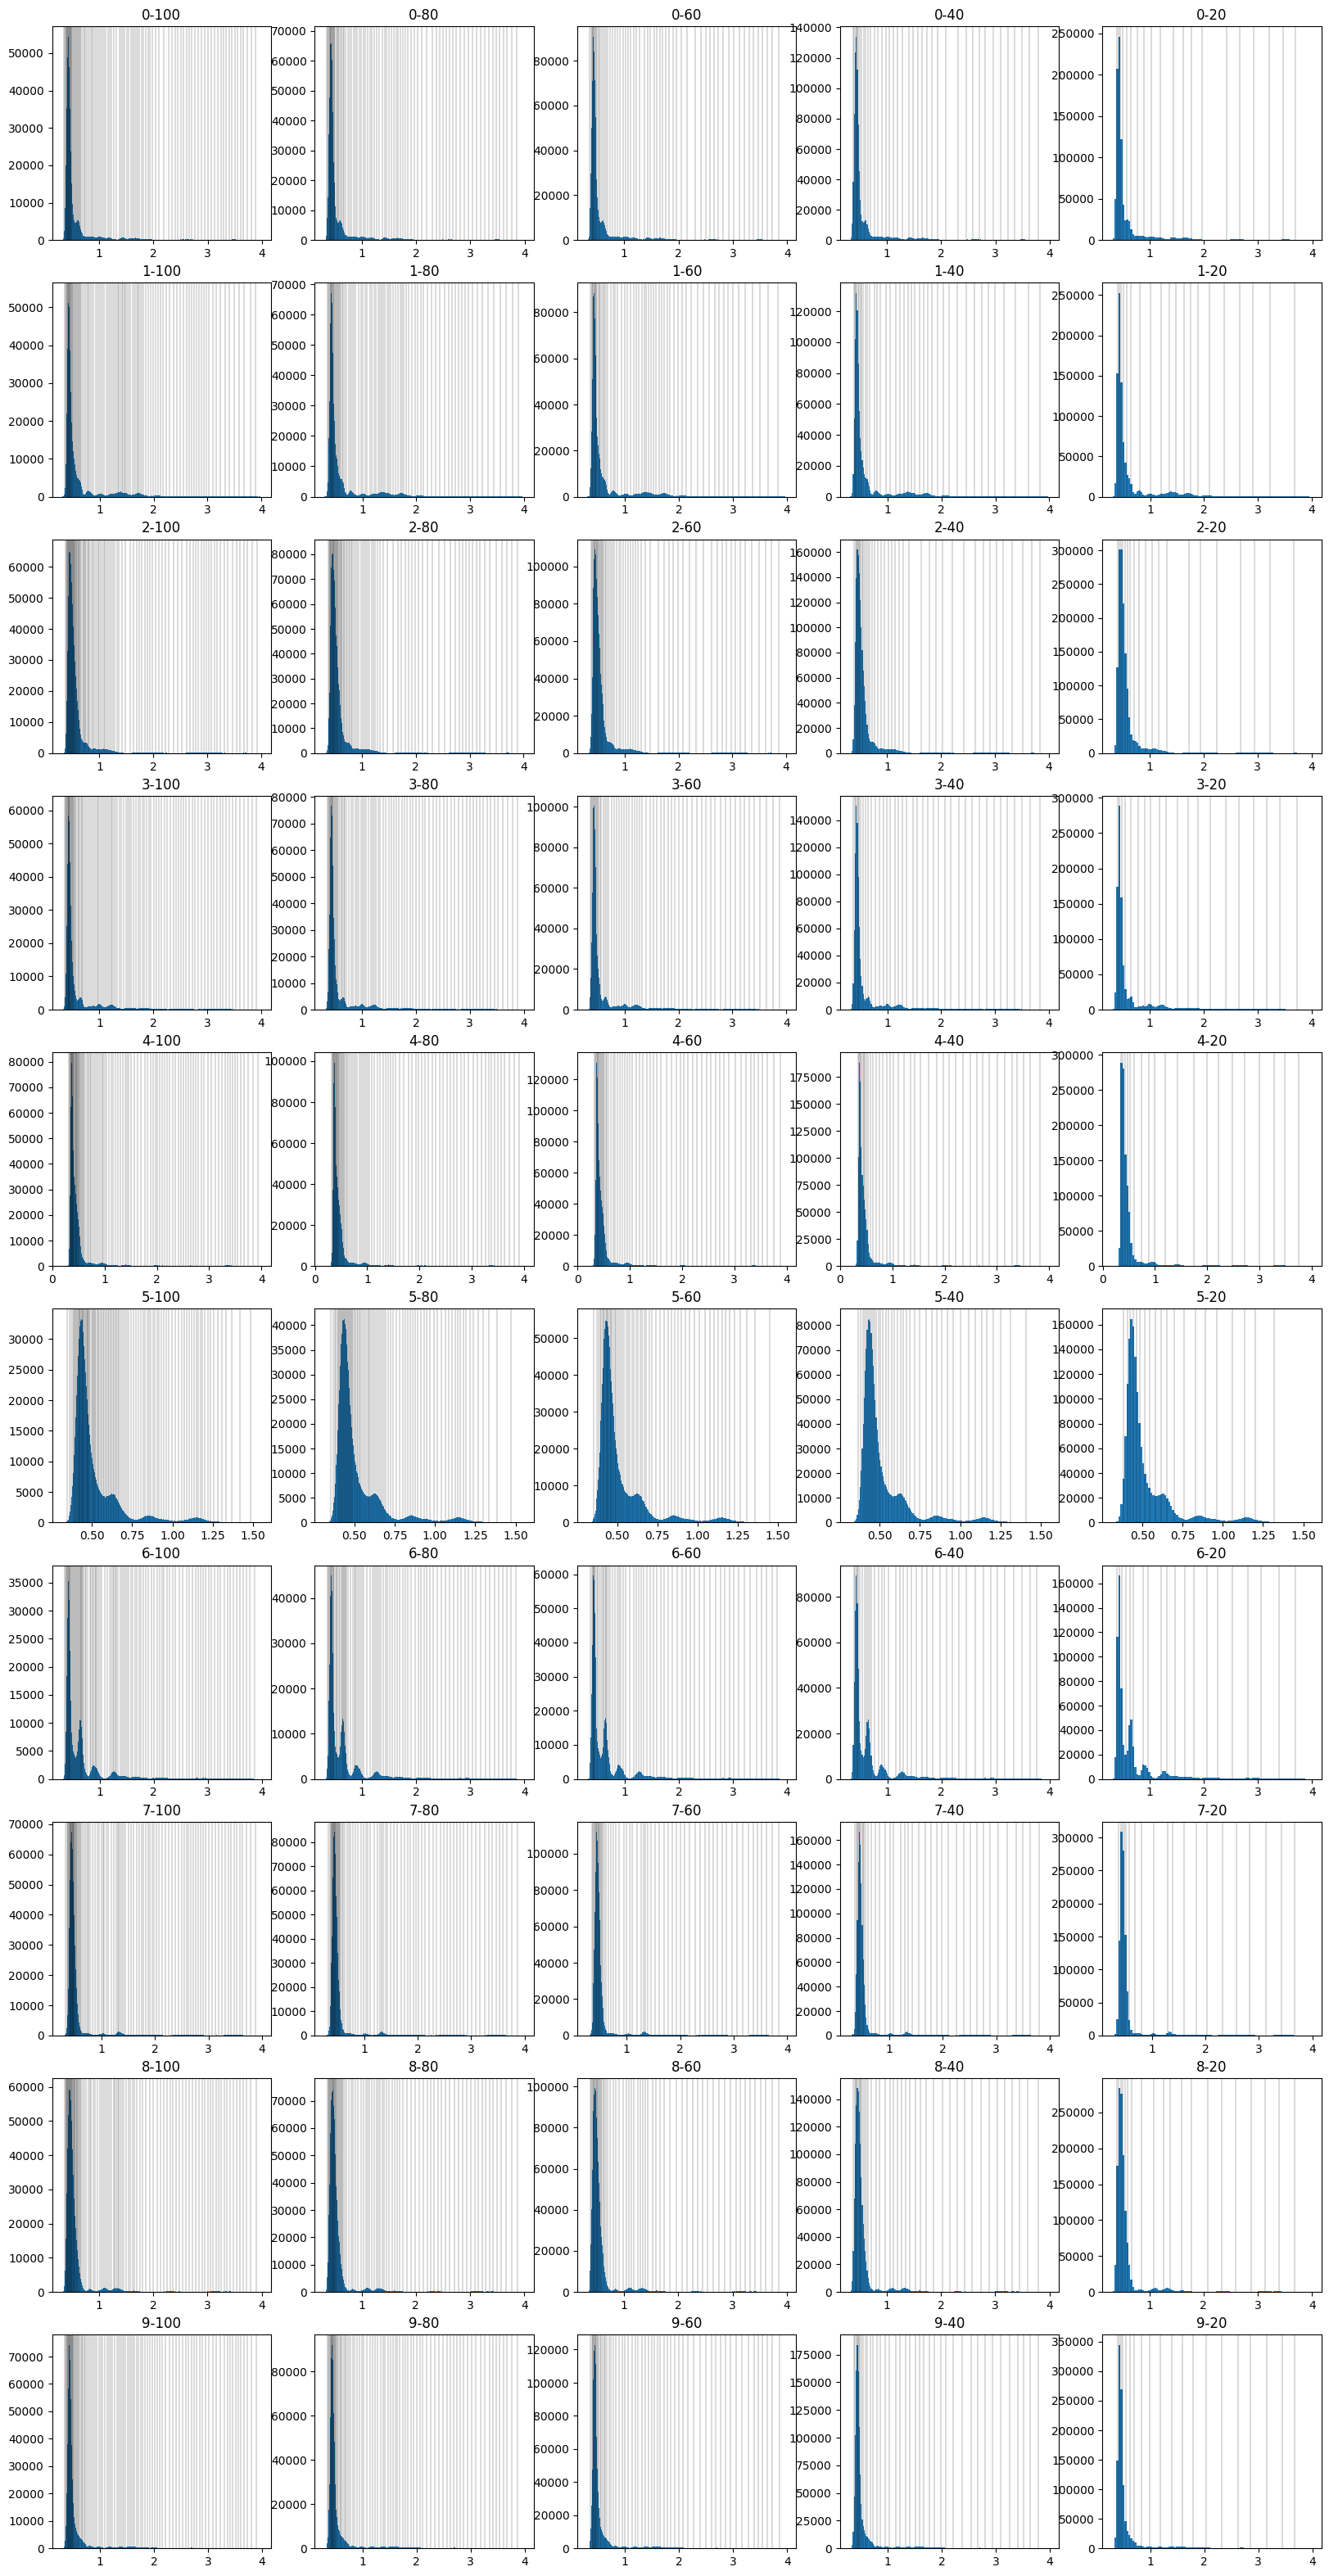

In [7]:
n_clusters_candidates = [100, 80, 60, 40, 20]

if False:
    clustered_trajs = [None for _ in range(len(trajs))]
    cluster_centers = [None for _ in range(len(trajs))]
    
    for trial in range(len(trajs)):
        clustered_trajs[trial] = {}
        cluster_centers[trial] = {}
        for i_clusters, n_clusters in enumerate(n_clusters_candidates):
            print(trial, n_clusters)
            clustered_trajs[trial][n_clusters], cluster_centers[trial][n_clusters] = cluster_trajs(trajs[trial], n_clusters)

    pickle.dump(clustered_trajs, open(f"{pickle_dir}/clustered_trajs.pickle", "wb"))
    pickle.dump(cluster_centers, open(f"{pickle_dir}/cluster_centers.pickle", "wb"))

clustered_trajs = pickle.load(open(f"{pickle_dir}/clustered_trajs.pickle", "rb"))
cluster_centers = pickle.load(open(f"{pickle_dir}/cluster_centers.pickle", "rb"))


fig_cluster, ax_cluster = plt.subplots(len(trajs), len(n_clusters_candidates))
fig_cluster.set_size_inches(4*len(n_clusters_candidates), 4*len(trajs))

for trial in range(len(trajs)):
    for i_clusters, n_clusters in enumerate(n_clusters_candidates):
        plot_clusters(ax_cluster[trial][i_clusters], trajs[trial], clustered_trajs[trial][n_clusters], cluster_centers[trial][n_clusters])
        ax_cluster[trial][i_clusters].set_title(f"{trial}-{n_clusters}")

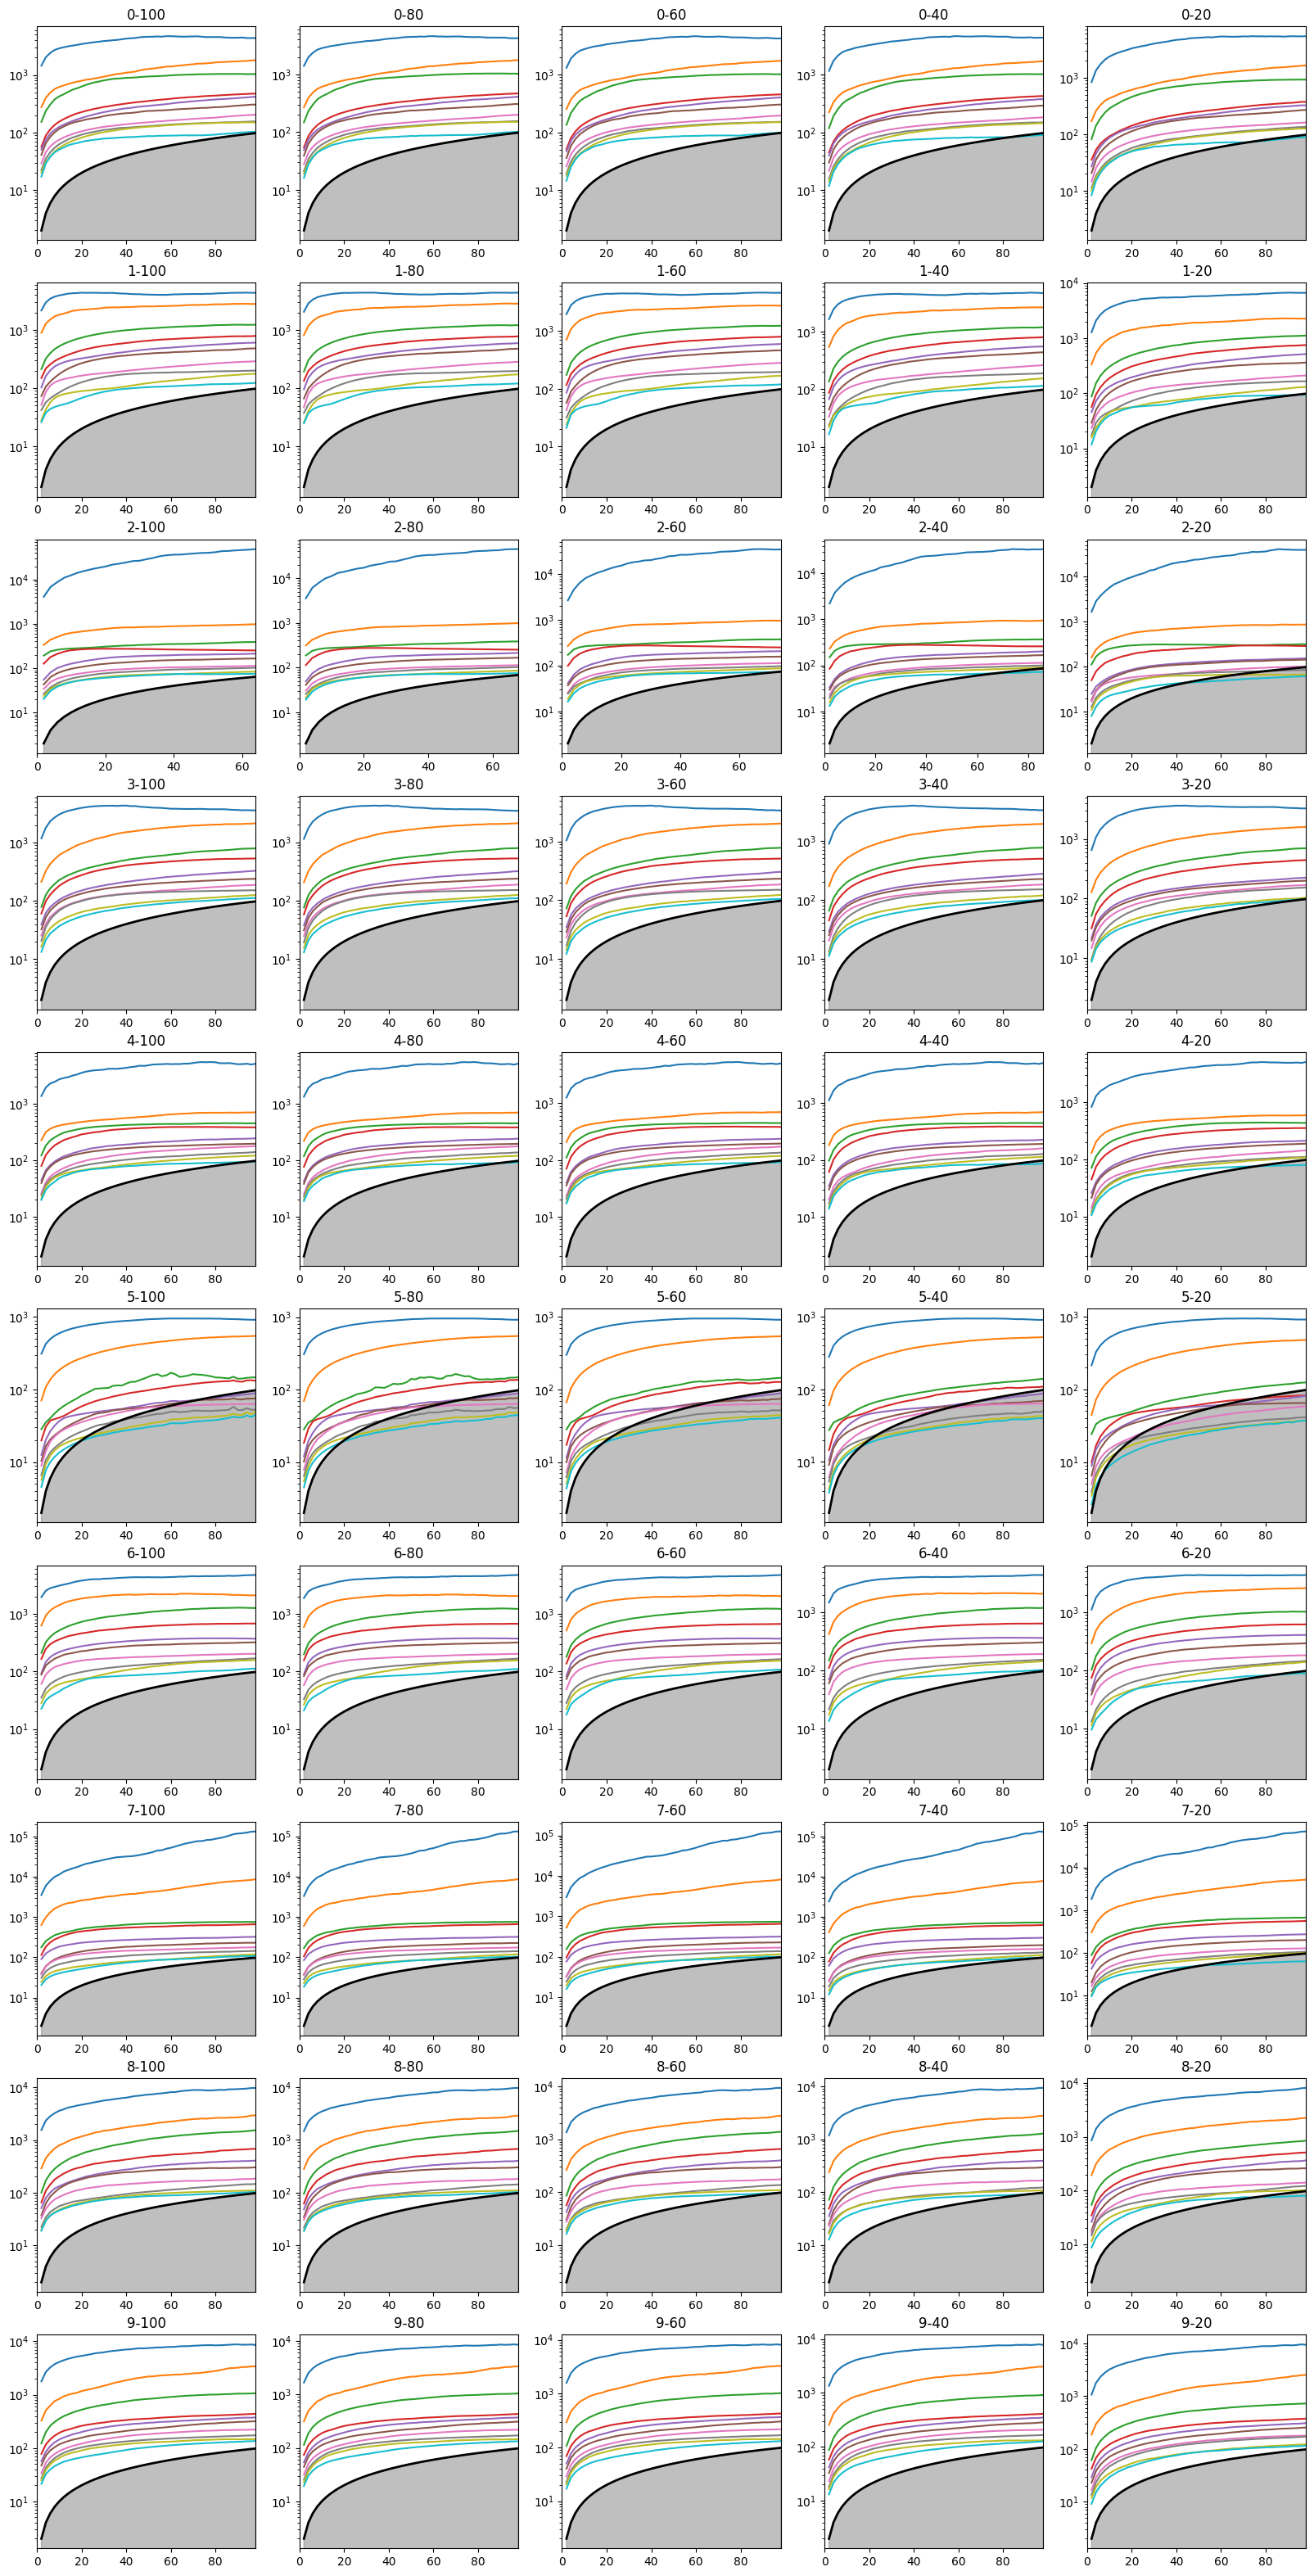

In [ ]:
if False:
    msm_models = [None for _ in range(len(trajs))]
    stationary_distributions = [None for _ in range(len(trajs))]
    
    for trial in range(len(trajs)):
        msm_models[trial] = {}
        stationary_distributions[trial] = {}
        for i_clusters, n_clusters in enumerate(n_clusters_candidates):
            print(trial, n_clusters)
            msm_models[trial][n_clusters], stationary_distributions[trial][n_clusters] = construct_msm(clustered_trajs[trial][n_clusters], range(2, int(N_TIMESTEP_IN_REPLICA/2), 2))

    pickle.dump(msm_models, open(f"{pickle_dir}/msm_models.pickle", "wb"))
    pickle.dump(stationary_distributions, open(f"{pickle_dir}/stationary_distributions.pickle", "wb"))

msm_models = pickle.load(open(f"{pickle_dir}/msm_models.pickle", "rb"))
stationary_distributions = pickle.load(open(f"{pickle_dir}/stationary_distributions.pickle", "rb"))


fig_its, ax_its = plt.subplots(len(trajs), len(n_clusters_candidates))
fig_its.set_size_inches(4*len(n_clusters_candidates), 4*len(trajs))

for trial in range(len(trajs)):
    for i_clusters, n_clusters in enumerate(n_clusters_candidates):
        plot_implied_timescales(ax_its[trial][i_clusters], msm_models[trial][n_clusters])
        ax_its[trial][i_clusters].set_title(f"{trial}-{n_clusters}")

In [ ]:
ers_candidates):
        plot_implied_timescales(ax_its[trial][i_clusters], msm_models[trial][n_clusters])
        ax_its[trial][i_clusters].set_title(f"{trial}-{n_clusters}")

In [9]:
import scipy.constants
from scipy.spatial import ConvexHull


def calculate_pmf(stationary_distributions):
    pmf = -np.log(stationary_distributions/max(stationary_distributions))
    pmf *= scipy.constants.Boltzmann
    pmf *= TEMPERATURE
    pmf *= scipy.constants.Avogadro
    pmf /= scipy.constants.calorie
    pmf /= 1000
    return pmf


def calculate_pmf_plot(cluster_centers, pmf, unbound_threshold):
    com_distances_cluster_centers = np.linalg.norm(cluster_centers, axis=1)
    indices_order = np.argsort(com_distances_cluster_centers)
    ordered_pmf = pmf[indices_order]
    ordered_cluster_centers = com_distances_cluster_centers[indices_order]

    pmf_baseline = []
    for i_cluster_center, (cluster_center, _pmf) in enumerate(zip(ordered_cluster_centers, ordered_pmf)):
        if unbound_threshold < cluster_center and np.isfinite(_pmf):
            pmf_baseline.append(_pmf)
    ordered_pmf -= np.mean(pmf_baseline)

    return ordered_cluster_centers, ordered_pmf


def plot_pmf(ax, ordered_cluster_centers, ordered_pmf, xmin, xmax, ymin, ymax, bound_threshold=None, unbound_threshold=None):
    ax.hlines(0, xmin=xmin, xmax=xmax, color="black")
    if bound_threshold != None and unbound_threshold != None:
        ax.vlines(bound_threshold,   ymin=ymin, ymax=ymax, color="black", linestyles="--")
        ax.vlines(unbound_threshold, ymin=ymin, ymax=ymax, color="black", linestyles="--")

    ax.plot(ordered_cluster_centers, ordered_pmf)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)


def calculate_g_pmf(cluster_centers, stationary_distributions, bound_threshold, unbound_threshold):
    bound_probability = 0
    unbound_probability = 0

    for cluster_center, stationary_distribution in zip(cluster_centers, stationary_distributions):
        com_distances_cluster_centers = np.linalg.norm(cluster_center)
        
        if com_distances_cluster_centers < bound_threshold:
            bound_probability += stationary_distribution
        if  unbound_threshold < com_distances_cluster_centers:
            unbound_probability += stationary_distribution

    g_pmf = -np.log(bound_probability/unbound_probability)
    g_pmf *= scipy.constants.Boltzmann
    g_pmf *= TEMPERATURE
    g_pmf *= scipy.constants.Avogadro
    g_pmf /= scipy.constants.calorie
    g_pmf /= 1000

    return g_pmf


def calculate_volume_correction(com_vectors, unbound_threshold):
    unbound_com_vectors = com_vectors[unbound_threshold < np.linalg.norm(com_vectors, axis=2)]
    hull = ConvexHull(unbound_com_vectors)

    volume_correction = -np.log(hull.volume/1.661)
    volume_correction *= scipy.constants.Boltzmann
    volume_correction *= TEMPERATURE
    volume_correction *= scipy.constants.Avogadro
    volume_correction /= scipy.constants.calorie
    volume_correction /= 1000

    return volume_correction

In [15]:
pmfs[5]

{100: {2: array([ 0.06329237,  3.5903015 ,  2.01635229,  4.04499039,  1.12346434,
          0.18652065,  2.55995658,  0.40946324,  4.80036608,  4.10667114,
          1.72472803, -0.        ,  3.72830179,  4.09707466,  0.46305832,
          0.28451389,  2.98822068,  2.28921022,  4.29216026,  3.97368074,
          0.02521169,  1.28530472,  5.62289319,  0.02546094,  0.62299917,
          1.4564302 ,  1.92957362,  3.58809701,  4.44755461,  3.6119672 ,
          0.17835608,  1.19694602,  4.32067039,  4.16200768,  5.12296913,
          0.04991897,  2.14235652,  3.88329717,  0.25730763,  2.3681719 ,
          4.04743897,  0.87274771,  6.37924637,  3.40242638,  1.84050927,
          0.35260626,  3.64566227,  0.09670877,  1.63625634,  4.32247663,
          0.3486029 ,  3.5449454 ,  4.1928979 ,  0.03836374,  4.07893873,
          3.77879821,  0.62270384,  4.02265583,  3.92155241,  0.46797414,
          0.12236144,  5.31869093,  2.08295978,  0.01407031,  0.00922458,
          3.79529089,  3.64894

In [10]:
pmfs = [None for _ in range(len(trajs))]

for trial in range(len(trajs)):
    pmfs[trial] = {}
    for i_clusters, n_clusters in enumerate(n_clusters_candidates):
        pmfs[trial][n_clusters] = {}
        for lagtime in stationary_distributions[trial][n_clusters]:
            try:
                pmfs[trial][n_clusters][lagtime] = calculate_pmf(stationary_distributions[trial][n_clusters][lagtime])
            except:
                continue

/gs/bs/tga-Kitao-Lab/yilan/softwares/miniconda3/envs/pacsmd2/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/gs/bs/tga-Kitao-Lab/yilan/softwares/miniconda3/envs/pacsmd2/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


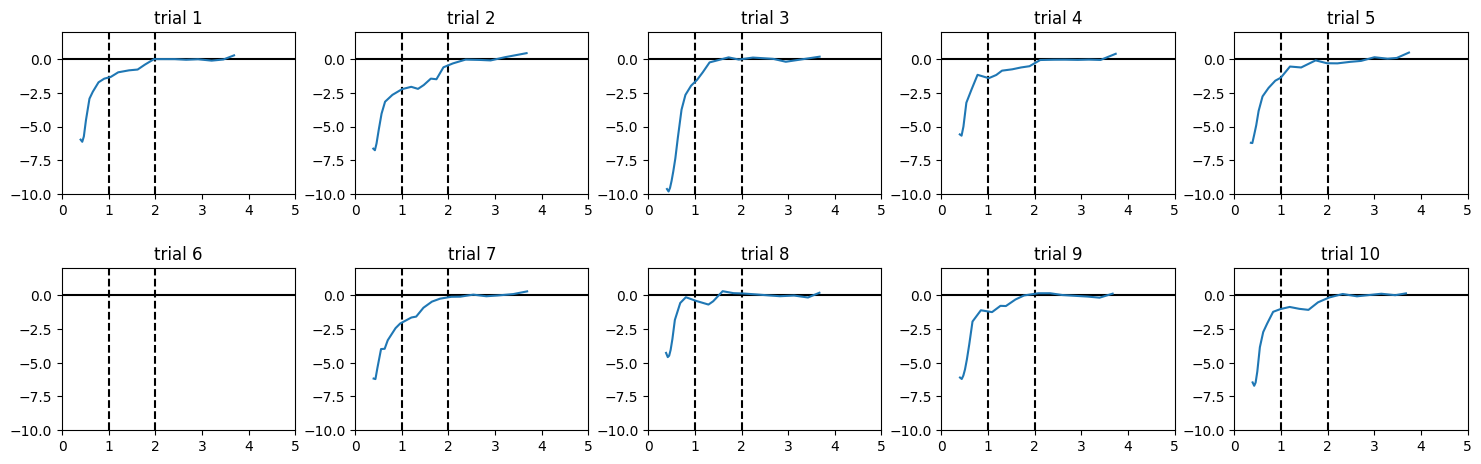

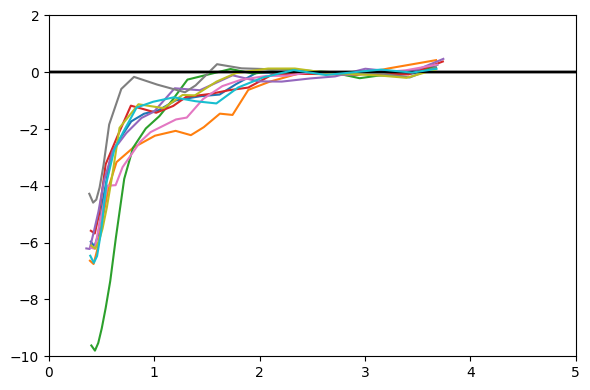

In [16]:
bound_thresholds = [1 for _ in range(len(trajs))]
unbound_thresholds = [2 for _ in range(len(trajs))]

n_clusters = [20 for _ in range(len(trajs))]
lagtimes   = [20 for _ in range(len(trajs))]
n_clusters = [20 for _ in range(len(trajs))]
lagtimes   = [20 for _ in range(len(trajs))]

#fig_trial, ax_trial = plt.subplots(1, len(trajs))
fig_trial, ax_trial = plt.subplots(2,5)
fig_trial.set_size_inches(1.5*len(trajs), 5)

fig_all, ax_all = plt.subplots(1,1)
fig_all.set_size_inches(6, 4)

ax_all.hlines(0, xmin=0, xmax=12, color="black")
for trial in range(len(trajs)):
    ordered_cluster_centers, ordered_pmf = calculate_pmf_plot(cluster_centers[trial][n_clusters[trial]], pmfs[trial][n_clusters[trial]][lagtimes[trial]], unbound_thresholds[trial])

    plot_pmf(ax_all,          ordered_cluster_centers, ordered_pmf, 0, 5, -10, 2)
    # plot_pmf(ax_trial[trial], ordered_cluster_centers, ordered_pmf, 0, 6, -10, 2, bound_threshold=bound_thresholds[trial], unbound_threshold=unbound_thresholds[trial])
    # ax_trial[trial].set_title(trial)
    row = trial // 5
    col = trial % 5

    plot_pmf(ax_trial[row, col], ordered_cluster_centers, ordered_pmf, 0, 5, -10, 2,
            bound_threshold=bound_thresholds[trial], unbound_threshold=unbound_thresholds[trial])
    ax_trial[row, col].set_title("trial " + str(trial+1))

fig_trial.tight_layout(pad=2.0, w_pad=1.5, h_pad=2.0)
fig_all.tight_layout()

fig_trial.savefig("pmf_each_trial.png", dpi=400, bbox_inches="tight")
fig_all.savefig("pmf_all_trials.png", dpi=400, bbox_inches="tight")

In [12]:
g_pmfs = np.zeros(len(trajs))
volume_corrections = np.zeros(len(trajs))
for trial in range(len(trajs)):
    g_pmfs[trial] = calculate_g_pmf(cluster_centers[trial][n_clusters[trial]], stationary_distributions[trial][n_clusters[trial]][lagtimes[trial]], bound_thresholds[trial], unbound_thresholds[trial])
    volume_corrections[trial] = calculate_volume_correction(pacs_com_vectors[trial], unbound_thresholds[trial])

g_stds = g_pmfs + volume_corrections

for trial in range(len(trajs)):
    print(trial, g_pmfs[trial], volume_corrections[trial], g_stds[trial])
print()
print("mean", g_pmfs.mean(), volume_corrections.mean(), g_stds.mean())
print("std ", g_pmfs.std(),  volume_corrections.std(),  g_stds.std())
g_stds

/tmp/73036.1.interactive/ipykernel_2365281/1698779254.py:53: RuntimeWarning: divide by zero encountered in scalar divide
  g_pmf = -np.log(bound_probability/unbound_probability)


ValueError: No points given

In [10]:
g_stds_ordered = []
for trial, g_std in enumerate(g_stds):
    g_stds_ordered.append((trial,  g_std))
g_stds_ordered.sort(key=lambda x: x[1], reverse=True)

print(g_stds_ordered)
print(f"[{','.join([str(val[0]) for val in g_stds_ordered])}]")

[(31, -5.183061199521127), (10, -6.138554241956816), (7, -6.621587772736612), (22, -6.652964753033664), (30, -6.784497086265064), (36, -6.7923516629860945), (16, -6.8851932966714955), (32, -7.1663110318171155), (3, -7.4672742306696165), (33, -7.640617043683281), (23, -7.668872528550122), (24, -7.674857193650327), (18, -7.681725438397169), (38, -7.685005500317116), (4, -8.022631676220119), (37, -8.138235938639248), (9, -8.18375010526962), (40, -8.30255403248914), (19, -8.504140956234586), (1, -8.575799313502523), (27, -8.602607137824148), (47, -8.647321309486355), (26, -8.725076300765332), (2, -8.917796299098622), (11, -8.94020095026998), (17, -8.98983045585526), (6, -9.232298396359816), (12, -9.325929927522987), (5, -9.352713569878256), (15, -9.479104816761584), (48, -9.606799481140799), (39, -9.61112924467606), (42, -9.65645842260059), (25, -9.693133362912715), (41, -9.963823066935799), (8, -9.965376279757173), (21, -10.041874537427164), (14, -10.127263228635258), (43, -10.13762957027